To analyze customer behavior using statistical and mathematical tools in Python, to
identify factors affecting customer retention and churn.
Get the dataset from :
https://drive.google.com/file/d/1VX-LFyvlpQf7T_6lMnco0DKn6-5PtA1q/view?usp=
drive_link
Dataset Description:
Assume a dataset with the following columns:
1. CustomerID
2. Gender
3. Region
4. PurchaseAmount
5. ProductCategory
6. Churn (Yes/No)
7. CampaignGroup (A/B)
Questions
1. What is the average, median, and mode of PurchaseAmount?
2. Are there any outliers in the PurchaseAmount data?
3. Is there any skewness or kurtosis in the PurchaseAmount distribution?
4. Is there a significant difference in spending between male and female
customers?
5. Is there a relationship between ProductCategory and customer churn?
6. Does PurchaseAmount vary significantly across different regions?
7. Which email campaign (A or B) performed better in terms of average
PurchaseAmount?
8. Can we assume PurchaseAmount follows a normal distribution?
9. What insights can we gain by applying the Central Limit Theorem?
10.What is the 95% confidence interval for the average PurchaseAmount?

In [12]:
import pandas as pd
import numpy as np
from scipy import stats

df=pd.read_csv('customer_behavior.csv')

purchase= df['PurchaseAmount'].dropna()
mean=purchase.mean()
median=purchase.median()
mode=purchase.mode()[0]
print(f"Mean: {mean}, Median: {median}, Mode: {mode}")
df.head()

Mean: 1003.9506701030928, Median: 998.0799999999999, Mode: 0.0


,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [10]:
Q1, Q3 = purchase.quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = purchase[(purchase < Q1 - 1.5*IQR) | (purchase > Q3 + 1.5*IQR)]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 15


In [13]:
skewness = purchase.skew()
kurtosis = purchase.kurtosis()
print(f"Skewness: {skewness}, Kurtosis: {kurtosis}")

Skewness: 0.10609189374631554, Kurtosis: -0.2615105545319705


In [15]:
male=df[df['Gender'] == 'Male']['PurchaseAmount'].dropna()
female=df[df['Gender'] == 'Female']['PurchaseAmount'].dropna()
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(male, female, equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 2.234798912073049, P-value: 0.025476849797238143


In [18]:
pd.crosstab(df['ProductCategory'], df['Churn'], margins=True)

Churn,No,Yes,All
ProductCategory,,,
Electronics,785,541,1326
Fashion,839,607,1446
Grocery,855,604,1459
All,2479,1752,4231


<Axes: xlabel='ProductCategory', ylabel='Region'>

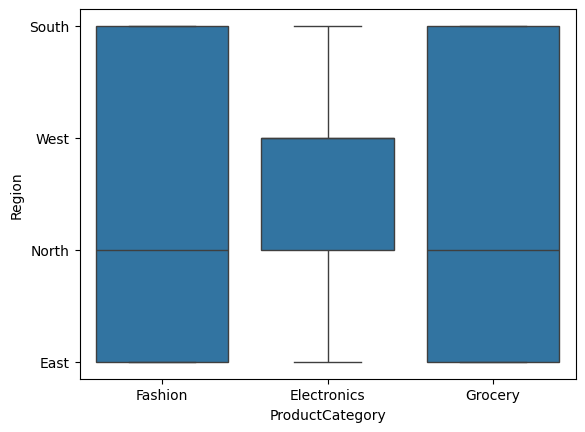

In [21]:
import seaborn as sns
sns.boxplot(x='ProductCategory', y='Region', data=df)

<Axes: title={'center': 'Average Purchase Amount by Campaign'}, xlabel='CampaignGroup'>

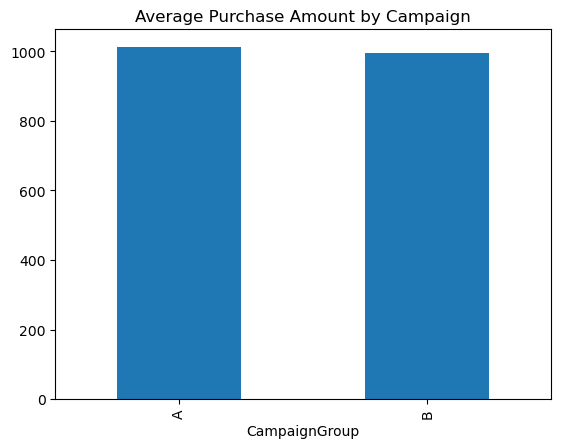

In [27]:
df.groupby('CampaignGroup')['PurchaseAmount'].mean().plot(kind='bar', title='Average Purchase Amount by Campaign')

In [35]:
from scipy.stats import shapiro
stat, p = shapiro(purchase.sample(500, random_state=1))
print(f"Shapiro-Wilk Test: Statistics={stat}, p-value={p}")

Shapiro-Wilk Test: Statistics=0.9901863422300459, p-value=0.0020465161079561882


<Axes: ylabel='Count'>

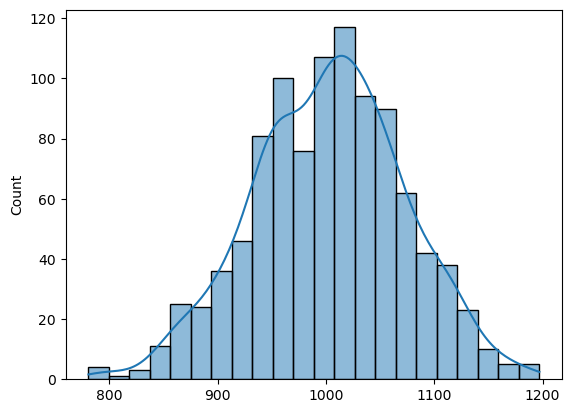

In [36]:
sample_means = [purchase.sample(50, replace=True).mean() for _ in range(1000)]
sns.histplot(sample_means, kde=True)

In [40]:
import math
mean=purchase.mean()
student=purchase.sem()
low = mean - 1.96*student
high = mean + 1.96*student
print(f"95% Confidence Interval: ({low}, {high})")

95% Confidence Interval: (990.3820977717656, 1017.5192424344199)
